## Partie 0 – Mise en place de l'environnement

### 4) Installer et importer seaborn, matplotlib et pandas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

### 5) Importer `mesures_capteurs.csv` dans le dataframe `df`

In [2]:
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


### 6) Explorer le dataframe `df`

In [23]:
print(f"shape : {df.shape}")
print("--*-**-*--*-**-*---*------*--*-*---*-*-*---*---*-*-*----*--*--*------*-*---*----*--*---*-----*---*-----*-*-*")
print(f"info :")

df.info()
print("--*-**-*--*-**-*-----*---*---*----*---*----*--*-*------*-----*-----*------*-----*-----*-*-------*----*-*--")

print(f"Description :")
df.describe()

shape : (596, 9)
--*-**-*--*-**-*---*------*--*-*---*-*-*---*---*-*-*----*--*--*------*-*---*----*--*---*-----*---*-----*-*-*
info :
<class 'pandas.DataFrame'>
Index: 596 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     596 non-null    str    
 1   date_heure    596 non-null    str    
 2   id_capteur    596 non-null    str    
 3   batiment      596 non-null    str    
 4   temperature   590 non-null    float64
 5   humidite      591 non-null    float64
 6   pression      591 non-null    float64
 7   consommation  591 non-null    float64
 8   etat          596 non-null    str    
dtypes: float64(4), str(5)
memory usage: 46.6 KB
--*-**-*--*-**-*-----*---*---*----*---*----*--*-*------*-----*-----*------*-----*-----*-*-------*----*-*--
Description :


,temperature,humidite,pression,consommation
count,590.000000,591.000000,591.000000,591.000000
mean,24.899712,64.830152,1012.205415,208.482166
std,4.073456,10.787337,10.648486,72.047854
min,-18.500000,28.520000,850.000000,18.120000
25%,22.620000,58.060000,1006.780000,160.500000
50%,24.870000,65.350000,1012.820000,206.130000
75%,27.295000,71.590000,1017.820000,253.810000
max,58.700000,145.000000,1038.430000,875.000000


---
## Partie 1 – Gestion des doublons

### 1) Vérifier l'existence de doublons

In [9]:
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")

Nombre de doublons : 5


### 2) Supprimer les doublons puis vérifier la suppression

In [12]:
df = df.drop_duplicates()
print(f"Nombre de doublons après suppression : {df.duplicated().sum()}")
print(f"Nouvelle taille du dataframe : {df.shape}")

Nombre de doublons après suppression : 0
Nouvelle taille du dataframe : (600, 9)


---
## Partie 2 – Sélection de y (cible) et X (caractéristiques)

### 1) Définir la cible et les caractéristiques

`etat` est la **cible** (ce qu'on veut prédire) ; `temperature`, `humidite`, `pression` et `consommation` sont les **caractéristiques** (les variables explicatives à partir desquelles on prédit).

On retire d'abord les lignes où la cible `etat` est manquante — un modèle ne peut pas apprendre à partir d'un exemple dont on ne connaît pas la bonne réponse.

In [13]:
# On ne garde que les lignes où la cible est connue
df = df.dropna(subset=["etat"])

caracteristiques = ["temperature", "humidite", "pression", "consommation"]

X = df[caracteristiques]
y = df["etat"]

print("Shape de X :", X.shape)
print("Shape de y :", y.shape)

Shape de X : (596, 4)
Shape de y : (596,)


### 2) Afficher les cinq premières lignes de X et de y

In [19]:
X.head()

,temperature,humidite,pression,consommation
0,25.46,58.06,1008.95,287.28
1,24.00,79.73,993.39,116.20
2,25.82,54.47,1010.32,288.50
3,28.23,69.39,1019.62,136.65
4,20.58,53.80,1016.58,182.62


In [20]:
y.head()

0    OK
1    OK
2    OK
3    OK
4    OK
Name: etat, dtype: str

### 3) Quel est le type du problème de machine learning ?

C'est un problème de **classification supervisée multiclasse** :
- **Supervisée**, car on dispose déjà de la bonne réponse (`etat`) pour chaque exemple d'entraînement.
- **Classification**, car la cible à prédire est une **catégorie** (`OK`, `ALERTE`, `ERREUR`), pas une valeur numérique continue (ce qui serait de la régression).
- **Multiclasse**, car il y a plus de deux catégories possibles (contrairement à une classification binaire qui n'en aurait que deux).

---
## Partie 3 – Découpage Train/Test

On divise `X` (et `y`) en un ensemble d'entraînement et un ensemble de test, avec :
- **20% des données pour le test** (`test_size=0.2`)
- **Reproductibilité** du découpage (`random_state` fixé, pour retomber sur le même découpage à chaque exécution)
- **Mêmes proportions de classes** dans train et test qu'à l'origine (`stratify=y`) — essentiel ici vu le fort déséquilibre entre `OK`, `ALERTE` et `ERREUR`

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("\nRépartition des classes dans y_train :")
print(y_train.value_counts(normalize=True).round(3))
print("\nRépartition des classes dans y_test :")
print(y_test.value_counts(normalize=True).round(3))

X_train : (476, 4)
X_test  : (120, 4)

Répartition des classes dans y_train :
etat
OK        0.943
ALERTE    0.048
ERREUR    0.008
Name: proportion, dtype: float64

Répartition des classes dans y_test :
etat
OK        0.942
ALERTE    0.050
ERREUR    0.008
Name: proportion, dtype: float64


---
## Partie 4 – Gestion des valeurs manquantes

### 1) Vérifier l'existence de valeurs manquantes

In [25]:
X_train.isna().sum()

temperature     5
humidite        4
pression        5
consommation    3
dtype: int64

### 2) Sélectionner `SimpleImputer` avec la médiane### 2) Sélectionner `SimpleImputer` avec la médiane

In [26]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

### 3) Qu’est-ce qui justifie le choix de la médiane ?

La médiane est **peu sensible aux valeurs extrêmes (outliers)**, contrairement à la moyenne. Dans l’atelier Seaborn, nous avons constaté que le dataset contient des valeurs aberrantes, comme une température de **-18 °C** ou une humidité supérieure à **100 %**.

Si nous utilisions la moyenne pour remplacer les valeurs manquantes, ces valeurs extrêmes pourraient fortement modifier le résultat et nous donner une valeur qui ne représente pas correctement un cas typique du dataset.

La médiane est donc plus adaptée ici, car elle reste **représentative de la valeur centrale de la distribution**, même en présence de valeurs aberrantes.

### 4) Trouver les paramètres (médianes) de l’imputeur sur `X_train`

L’imputeur est calibré **uniquement sur `X_train`**, et jamais sur `X_test`. Cela permet d’éviter une **fuite d’information (*data leakage*)**.

En effet, lors de l’entraînement, le modèle ne doit avoir accès qu’aux informations provenant des données d’entraînement. Les données de test doivent rester **inconnues jusqu’à l’évaluation finale**.

Ainsi, les médianes calculées sur `X_train` sont ensuite utilisées pour remplacer les valeurs manquantes dans `X_train` et `X_test`.


In [27]:
imputer.fit(X_train)

# Les médianes apprises, une par colonne
pd.Series(imputer.statistics_, index=caracteristiques)

temperature       24.90
humidite          65.38
pression        1012.30
consommation     206.59
dtype: float64

### 5) Déterminer `X_train_imputed` et `X_test_imputed`

In [28]:
X_train_imputed = pd.DataFrame(imputer.transform(X_train), columns=caracteristiques, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=caracteristiques, index=X_test.index)

print("Valeurs manquantes restantes dans X_train_imputed :", X_train_imputed.isna().sum().sum())
print("Valeurs manquantes restantes dans X_test_imputed  :", X_test_imputed.isna().sum().sum())

Valeurs manquantes restantes dans X_train_imputed : 0
Valeurs manquantes restantes dans X_test_imputed  : 0


---
## Partie 5 – Mise à l'échelle

### 1) Sélectionner `StandardScaler`

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

### 2) Qu'est-ce qui justifie la standardisation ?

Les 4 caractéristiques n'ont pas du tout la même échelle : la température varie sur quelques dizaines de degrés, la pression sur plusieurs centaines d'hPa, la consommation sur des centaines de kWh. Or **KNN (utilisé en Partie 6) calcule des distances entre points** pour trouver les voisins les plus proches — sans standardisation, une variable avec de grandes valeurs (comme la pression) dominerait artificiellement le calcul de distance, au détriment des autres variables, même si elle n'est pas plus importante pour prédire l'état du capteur.

### 3) Trouver les paramètres (moyennes et écarts-types) sur `X_train_imputed`

Là encore, on calibre uniquement sur les données d'entraînement, pour la même raison qu'à la partie précédente.

In [30]:
scaler.fit(X_train_imputed)

print("Moyennes :", dict(zip(caracteristiques, scaler.mean_.round(2))))
print("Écarts-types :", dict(zip(caracteristiques, scaler.scale_.round(2))))

Moyennes : {'temperature': np.float64(24.96), 'humidite': np.float64(64.85), 'pression': np.float64(1012.08), 'consommation': np.float64(210.15)}
Écarts-types : {'temperature': np.float64(4.19), 'humidite': np.float64(10.16), 'pression': np.float64(10.99), 'consommation': np.float64(73.42)}


### 4) Déterminer `X_train_scaled` et `X_test_scaled`

In [31]:
X_train_scaled = pd.DataFrame(scaler.transform(X_train_imputed), columns=caracteristiques, index=X_train_imputed.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=caracteristiques, index=X_test_imputed.index)

X_train_scaled.describe().round(2)

,temperature,humidite,pression,consommation
count,476.00,476.00,476.00,476.00
mean,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00
min,-10.37,-2.86,-14.74,-2.62
25%,-0.55,-0.66,-0.49,-0.68
50%,-0.02,0.05,0.02,-0.05
75%,0.56,0.66,0.52,0.61
max,8.05,2.78,2.40,9.06


**Vérification :** après standardisation, chaque colonne de `X_train_scaled` a une moyenne proche de 0 et un écart-type proche de 1 (visible dans le tableau ci-dessus) — c'est exactement l'effet recherché.

---
## Partie 6 – Entraînement et prédiction d'un modèle

### 1) Sélectionner le modèle KNN avec 5 voisins

In [32]:
from sklearn.neighbors import KNeighborsClassifier

modele = KNeighborsClassifier(n_neighbors=5)

### 2) Entraîner le modèle

In [33]:
modele.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['ALERTE','ERREUR','OK']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


### 3) Déterminer `y_pred`, la prédiction du modèle sur l'ensemble de test

In [34]:
y_pred = modele.predict(X_test_scaled)
y_pred[:10]

array(['OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK', 'OK'],
      dtype=object)

### 4) Afficher quelques prédictions

In [35]:
pd.DataFrame({"prediction": y_pred[:10]})

,prediction
0,OK
1,OK
2,OK
3,OK
4,OK
5,OK
6,OK
7,OK
8,OK
9,OK


### 5) Comparer ces prédictions avec les vraies valeurs

In [36]:
comparaison = pd.DataFrame({
    "vraie_valeur": y_test.values[:10],
    "prediction": y_pred[:10]
})
comparaison["correct"] = comparaison["vraie_valeur"] == comparaison["prediction"]
comparaison

,vraie_valeur,prediction,correct
0,OK,OK,True
1,OK,OK,True
2,OK,OK,True
3,OK,OK,True
4,ALERTE,OK,False
5,OK,OK,True
6,OK,OK,True
7,OK,OK,True
8,OK,OK,True
9,OK,OK,True


---
## Partie 7 – Évaluation du modèle

### 1) Évaluer le modèle avec Accuracy

In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy:.3f}")

Accuracy : 0.958


### 2) Pourquoi l'Accuracy ne suffit-elle pas toujours ?

Parce que le dataset est **déséquilibré** (rappel : 567 `OK` contre seulement 5 `ERREUR`). Un modèle un peu paresseux qui prédirait **toujours** `OK`, sans même regarder les données, obtiendrait déjà une accuracy très élevée (autour de 93-94%) — tout en étant complètement inutile pour ce qu'on veut vraiment détecter : les `ALERTE` et les `ERREUR`. L'accuracy cache donc les mauvaises performances sur les classes minoritaires, qui sont pourtant les plus importantes à repérer ici (une erreur de capteur non détectée est plus grave qu'un capteur en état OK bien classé).

### 3) Matrice de confusion

In [38]:
from sklearn.metrics import confusion_matrix

classes = modele.classes_
matrice = confusion_matrix(y_test, y_pred, labels=classes)

pd.DataFrame(matrice, index=[f"Vrai {c}" for c in classes], columns=[f"Prédit {c}" for c in classes])

,Prédit ALERTE,Prédit ERREUR,Prédit OK
Vrai ALERTE,2,0,4
Vrai ERREUR,1,0,0
Vrai OK,0,0,113


**Commentaire :** la diagonale de cette matrice montre le nombre de prédictions correctes pour chaque classe. Les cases en dehors de la diagonale montrent les confusions du modèle (par exemple, une mesure réellement en `ALERTE` prédite à tort comme `OK`). Vu le peu d'exemples `ALERTE` et `ERREUR` dans le jeu de test, quelques erreurs sur ces classes suffisent à faire chuter fortement leurs métriques, même si l'accuracy globale reste élevée.

### 4) Visualiser cette matrice avec Seaborn

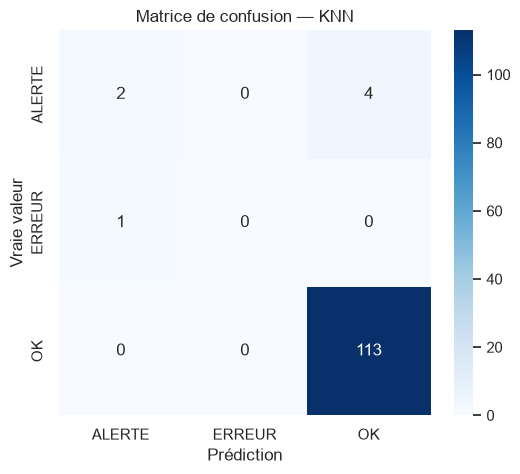

In [39]:
plt.figure(figsize=(6, 5))
sns.heatmap(matrice, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes)
plt.xlabel("Prédiction")
plt.ylabel("Vraie valeur")
plt.title("Matrice de confusion — KNN")
plt.show()

### 5) Rapport de classification

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      ALERTE       0.67      0.33      0.44         6
      ERREUR       0.00      0.00      0.00         1
          OK       0.97      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.54      0.44      0.48       120
weighted avg       0.94      0.96      0.95       120



c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

**Commentaire :** le rapport confirme ce qu'on pressentait — la classe `OK` a une precision et un recall très élevés (beaucoup d'exemples pour apprendre), tandis que `ALERTE` et surtout `ERREUR` ont des scores nettement plus faibles voire nuls, faute d'exemples suffisants pour que le modèle apprenne à bien les reconnaître.

### 6) Dans quel cas privilégier chaque métrique ?

- **Precision** — à privilégier quand le coût d'une **fausse alerte** est élevé : par exemple, si chaque `ALERTE` prédite déclenche une intervention technique coûteuse, on veut être sûr que les alertes prédites sont réellement des alertes (peu de faux positifs).
- **Recall** — à privilégier quand le coût de **rater un vrai cas positif** est élevé : ici, rater une vraie `ERREUR` de capteur pourrait être dangereux (panne non détectée) — on préfère alors quitte à avoir plus de fausses alertes, ne manquer aucune vraie erreur.
- **F1-score** — utile quand on veut un **compromis équilibré** entre precision et recall, notamment quand les classes sont déséquilibrées (exactement notre cas ici) et qu'aucune des deux erreurs (faux positif / faux négatif) n'est clairement plus grave que l'autre.
- **Accuracy** — pertinente seulement quand les classes sont **à peu près équilibrées** ; dans notre cas (très déséquilibré), elle est trompeuse, comme vu à la question 2.